# Notebook 04 Р Р†Р вЂљРІР‚Сњ EDA & Preprocessing: Hospital Readmission Risk (Case 2)

**Goal**: Predict 30-day hospital readmission risk (binary) from the UCI Diabetes 130-US Hospitals dataset.  
**Target**: `readmitted` Р Р†РІР‚В РІР‚в„ў binary: `1` if `<30` (readmitted within 30 days), else `0`.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, json, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
DATA_PATH = '../data/diabetic_data.csv'
MAPPING_PATH = '../data/IDS_mapping.csv'
MODELS_DIR = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Load Data

In [48]:
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head(3)

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [49]:
# Load IDS mapping for human-readable labels (used for reference)
ids_map_raw = pd.read_csv(MAPPING_PATH)
print('IDS Mapping shape:', ids_map_raw.shape)
ids_map_raw.head(20)

IDS Mapping shape: (67, 2)


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


## 2. Target Variable

Convert 3-class `readmitted` to binary:
- `1` = readmitted within 30 days (`<30`)
- `0` = not readmitted or readmitted after 30 days

Original target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64
Positive rate: 0.112


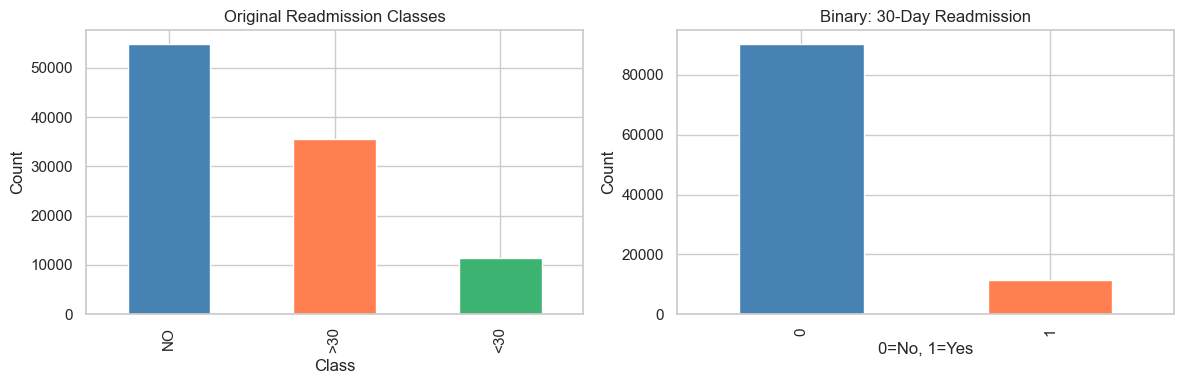

In [50]:
df = df_raw.copy()

print('Original target distribution:')
print(df['readmitted'].value_counts())

df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print('\nBinary target distribution:')
print(df['readmitted_30d'].value_counts())
print(f'Positive rate: {df["readmitted_30d"].mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral','mediumseagreen'])
axes[0].set_title('Original Readmission Classes')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
df['readmitted_30d'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Binary: 30-Day Readmission')
axes[1].set_xlabel('0=No, 1=Yes'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [51]:
# Remove encounters where patient was discharged expired or to hospice
# These patients cannot be readmitted РІР‚вЂќ including them biases the model
# discharge_disposition_id: 11=Expired, 13=Hospice/home, 14=Hospice/medical
dead_hospice_ids = [11, 13, 14, 19, 20, 21]  # died or discharged to hospice/palliate
n_before = len(df)
df = df[~df['discharge_disposition_id'].isin(dead_hospice_ids)].copy()
print(f'Removed {n_before - len(df)} expired/hospice encounters ({n_before - len(df)} rows)')
print(f'Remaining: {len(df)} rows')
print(f'Positive rate after removal: {df["readmitted_30d"].mean():.4f}')

Removed 2423 expired/hospice encounters (2423 rows)
Remaining: 99343 rows
Positive rate after removal: 0.1139


In [52]:
# Deduplicate by patient: keep only the LAST encounter per patient
# Multiple encounters from same patient across train/test would cause data leakage
# (model sees the same patient in both train and test)
# Keep last encounter as it captures most recent clinical state
n_before = len(df)
n_patients_before = df['patient_nbr'].nunique()
df = df.sort_values('encounter_id').groupby('patient_nbr').last().reset_index()
n_after = len(df)
print(f'Before deduplication: {n_before} encounters, {n_patients_before} unique patients')
print(f'After deduplication:  {n_after} rows (one per patient)')
print(f'Removed {n_before - n_after} duplicate encounters')
pos_rate = df['readmitted_30d'].mean()
print(f'Positive rate after dedup: {pos_rate:.4f}')


Before deduplication: 99343 encounters, 69990 unique patients
After deduplication:  69990 rows (one per patient)
Removed 29353 duplicate encounters
Positive rate after dedup: 0.0496


## 3. Missing Values & Data Quality

In [53]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                   missing_count  missing_pct
weight                     67208        96.03
max_glu_serum              66493        95.00
A1Cresult                  54770        78.25
medical_specialty          33676        48.12
payer_code                 29494        42.14
race                        1850         2.64
diag_3                      1142         1.63
diag_2                       289         0.41
diag_1                        16         0.02


In [54]:
# Drop columns with >90% missing or low-utility identifiers
cols_to_drop = [
    'weight',           # 97% missing
    'payer_code',       # 40% missing, low clinical value
    'encounter_id',     # identifier
    'patient_nbr',      # identifier
    'readmitted',       # original target (replaced by readmitted_30d)
]

# Also drop near-constant medication columns (examide, citoglipton always 'No')
near_constant = ['examide', 'citoglipton', 'acetohexamide', 'tolbutamide', 'troglitazone', 'tolazamide']
cols_to_drop += near_constant

df.drop(columns=cols_to_drop, inplace=True)
print('Remaining columns:', len(df.columns))
print(df.columns.tolist())

Remaining columns: 40
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_30d']


## 4. Feature Engineering

### 4.1 Diagnosis Features (ICD-9 Р Р†РІР‚В РІР‚в„ў Disease Category)

In [55]:
def icd9_to_category(code):
    """Map ICD-9 code to broad disease category."""
    if pd.isna(code):
        return 'Other'
    code = str(code).strip()
    # V and E codes
    if code.startswith('V'):
        return 'External'
    if code.startswith('E'):
        return 'External'
    try:
        c = float(code)
    except ValueError:
        return 'Other'
    if 390 <= c <= 459 or c == 785:
        return 'Circulatory'
    if 460 <= c <= 519 or c == 786:
        return 'Respiratory'
    if 520 <= c <= 579 or c == 787:
        return 'Digestive'
    if 250 <= c <= 250.99:
        return 'Diabetes'
    if 800 <= c <= 999:
        return 'Injury'
    if 710 <= c <= 739:
        return 'Musculoskeletal'
    if 580 <= c <= 629 or c == 788:
        return 'Genitourinary'
    if 140 <= c <= 239:
        return 'Neoplasms'
    return 'Other'

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    df[diag_col + '_cat'] = df[diag_col].apply(icd9_to_category)

print('diag_1_cat value counts:')
print(df['diag_1_cat'].value_counts())

diag_1_cat value counts:
diag_1_cat
Circulatory        20857
Other              11353
Respiratory         9528
Digestive           6529
Diabetes            5651
Injury              4922
Musculoskeletal     3885
Genitourinary       3569
Neoplasms           2500
External            1196
Name: count, dtype: int64


In [56]:
# Drop original diagnosis codes (replaced by categories)
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

### 4.2 Age Encoding

In [57]:
# Age is given as brackets: '[0-10)', '[10-20)', ..., '[90-100)'
print(df['age'].unique())

age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
    '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)
df.drop(columns=['age'], inplace=True)
print('age_numeric sample:', df['age_numeric'].describe())

<StringArray>
[ '[50-60)',  '[80-90)',  '[30-40)',  '[60-70)',  '[40-50)',  '[70-80)',
  '[10-20)', '[90-100)',  '[20-30)',   '[0-10)']
Length: 10, dtype: str
age_numeric sample: count    69990.000000
mean        65.658523
std         15.995519
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age_numeric, dtype: float64


### 4.3 Medication Change Features

In [58]:
# Medication columns: No, Steady, Up, Down Р Р†РІР‚В РІР‚в„ў encode as change indicator
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in med_cols:
    if col in df.columns:
        df[col + '_prescribed'] = (df[col] != 'No').astype(int)
        df[col + '_changed'] = df[col].isin(['Up', 'Down']).astype(int)
        df.drop(columns=[col], inplace=True)

print('Columns after medication encoding:', df.shape[1])

Columns after medication encoding: 57


### 4.4 Other Categorical Features

In [59]:
# Gender: encode as binary (1=Male, 0=Female/Other)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0}).fillna(0).astype(int)

# Race: fill missing with 'Unknown', then one-hot
df['race'] = df['race'].fillna('Unknown')

# A1Cresult and max_glu_serum: ordinal
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
df['A1Cresult'] = df['A1Cresult'].map(a1c_map).fillna(0).astype(int)
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map).fillna(0).astype(int)

# change and diabetesMed: binary
df['change'] = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# medical_specialty: fill missing with 'Unknown'
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

print(df.dtypes.value_counts())
df.head(3)

int64    52
str       5
Name: count, dtype: int64


,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,glyburide-metformin_prescribed,glyburide-metformin_changed,glipizide-metformin_prescribed,glipizide-metformin_changed,glimepiride-pioglitazone_prescribed,glimepiride-pioglitazone_changed,metformin-rosiglitazone_prescribed,metformin-rosiglitazone_changed,metformin-pioglitazone_prescribed,metformin-pioglitazone_changed
0,Caucasian,0,1,1,7,3,Surgery-Cardiovascular/Thoracic,31,1,14,...,0,0,0,0,0,0,0,0,0,0
1,Caucasian,0,3,1,1,2,Surgery-Neuro,49,1,11,...,0,0,0,0,0,0,0,0,0,0
2,Caucasian,0,1,3,7,4,InternalMedicine,68,2,23,...,0,0,0,0,0,0,0,0,0,0


In [60]:
# One-hot encode remaining categoricals
cat_cols = ['race', 'medical_specialty', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

# admission_type_id, discharge_disposition_id, admission_source_id Р Р†РІР‚В РІР‚в„ў treat as categorical
for col in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']:
    df[col] = df[col].astype(str)
df = pd.get_dummies(df, columns=['admission_type_id', 'discharge_disposition_id', 'admission_source_id'],
                    drop_first=False, dtype=int)

print('Shape after one-hot encoding:', df.shape)

Shape after one-hot encoding: (69990, 201)


In [61]:
### 4.5 Aggregate & Interaction Features
# Prior utilization: strong predictor of readmission
df['num_prior_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['inpatient_ratio'] = df['number_inpatient'] / (df['num_prior_visits'] + 1)

# Medication burden
med_prescribed_cols = [c for c in df.columns if c.endswith('_prescribed')]
med_changed_cols = [c for c in df.columns if c.endswith('_changed')]
df['total_meds_prescribed'] = df[med_prescribed_cols].sum(axis=1)
df['total_med_changes'] = df[med_changed_cols].sum(axis=1)

# Clinical severity proxies
df['procedures_per_day'] = df['num_procedures'] / (df['time_in_hospital'] + 1)
df['labs_per_day'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)
df['meds_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 1)

print('Added aggregate features. New shape:', df.shape)
new_feats = ['num_prior_visits', 'inpatient_ratio', 'total_meds_prescribed',
             'total_med_changes', 'procedures_per_day', 'labs_per_day', 'meds_per_day']
print(df[new_feats + ['readmitted_30d']].groupby('readmitted_30d').mean().round(3))

Added aggregate features. New shape: (69990, 208)
                num_prior_visits  inpatient_ratio  total_meds_prescribed  \
readmitted_30d                                                             
0                          0.885            0.132                  1.177   
1                          1.746            0.253                  1.198   

                total_med_changes  procedures_per_day  labs_per_day  \
readmitted_30d                                                        
0                           0.265               0.326         9.918   
1                           0.303               0.264         9.757   

                meds_per_day  
readmitted_30d                
0                      3.505  
1                      3.386  


## 5. EDA on Key Features

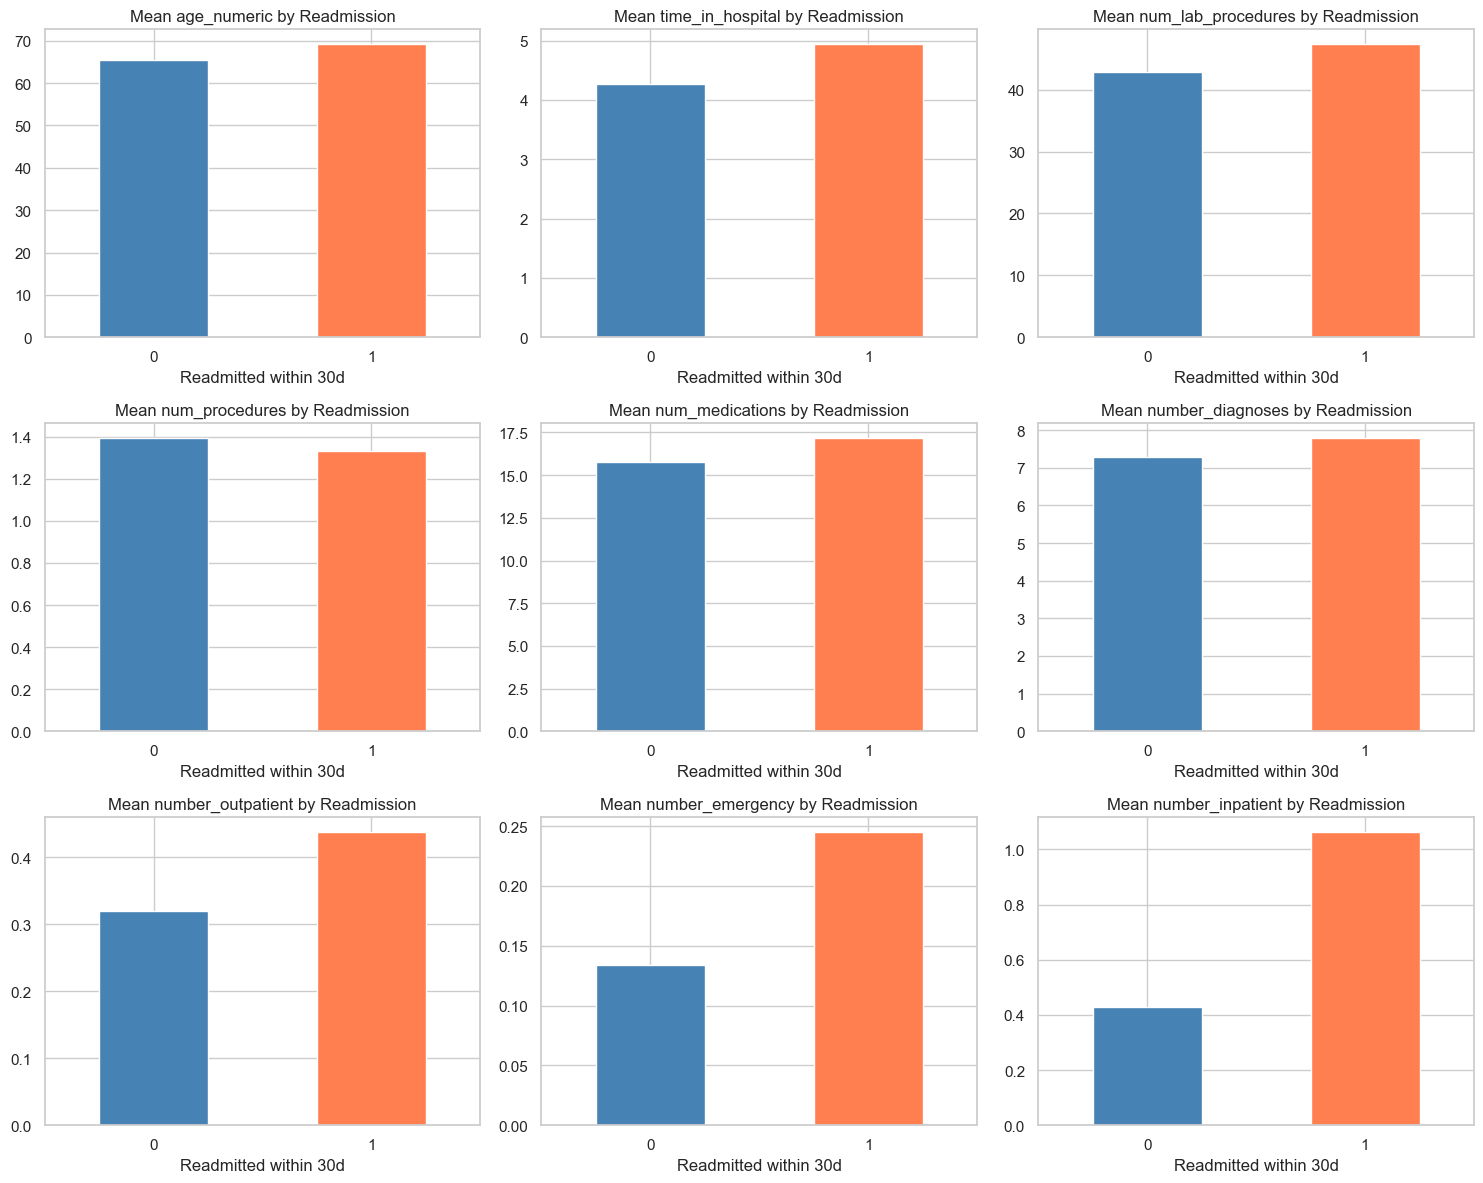

In [62]:
numeric_features = [
    'age_numeric', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_diagnoses',
    'number_outpatient', 'number_emergency', 'number_inpatient'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    df.groupby('readmitted_30d')[col].mean().plot(kind='bar', ax=axes[i], color=['steelblue','coral'])
    axes[i].set_title(f'Mean {col} by Readmission')
    axes[i].set_xlabel('Readmitted within 30d')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

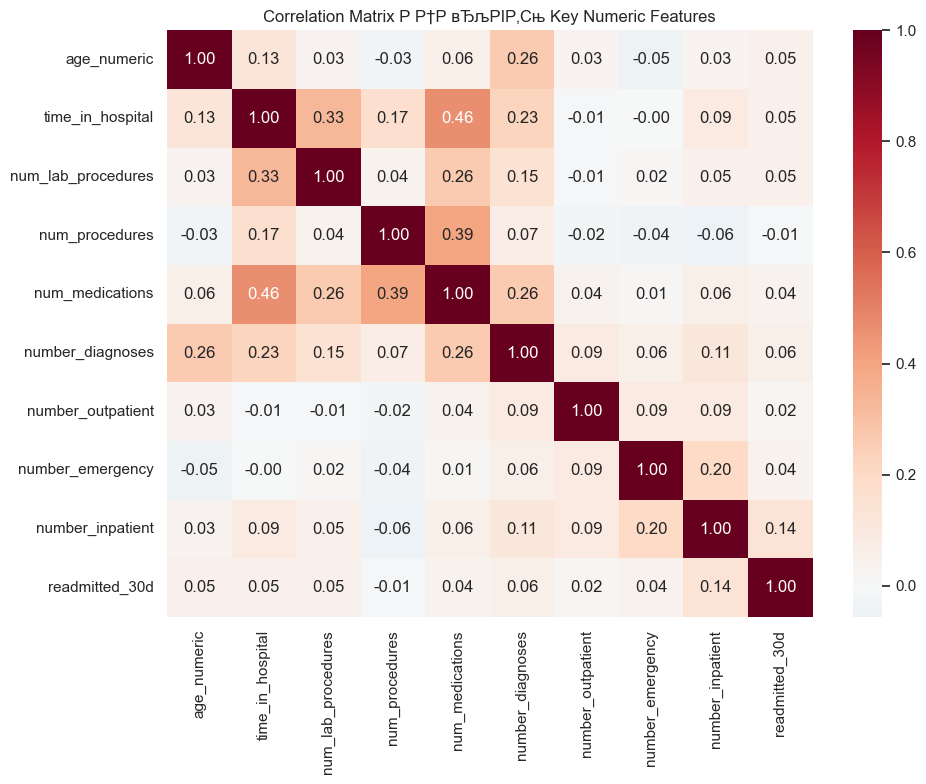

In [63]:
# Correlation heatmap for numeric features
corr_cols = numeric_features + ['readmitted_30d']
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix Р Р†Р вЂљРІР‚Сњ Key Numeric Features')
plt.tight_layout()
plt.show()

## 6. Train/Test Split

In [64]:
from sklearn.model_selection import train_test_split

y = df['readmitted_30d']
X = df.drop(columns=['readmitted_30d'])

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Positive rate:', y.mean().round(4))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Test positive rate: {y_test.mean():.4f}')

Features shape: (69990, 207)
Target shape: (69990,)
Positive rate: 0.0496

Train: (55992, 207), Test: (13998, 207)
Train positive rate: 0.0496
Test positive rate: 0.0496


## 7. Preprocessing Pipeline

In [65]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

class ReadmissionPreprocessor(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible preprocessor for the hospital readmission dataset.
    Applies median imputation and standard scaling to numeric columns.
    Binary/one-hot columns are passed through unchanged.
    """
    def __init__(self):
        self.numeric_cols_ = None
        self.imputer_ = SimpleImputer(strategy="median")
        self.scaler_ = StandardScaler()
        self.feature_names_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.feature_names_ = list(X.columns)
        # Base continuous features + new aggregate features
        base_numeric = [
            "age_numeric", "time_in_hospital", "num_lab_procedures",
            "num_procedures", "num_medications", "number_diagnoses",
            "number_outpatient", "number_emergency", "number_inpatient",
            "A1Cresult", "max_glu_serum",
            # Aggregate features added in 4.5
            "num_prior_visits", "inpatient_ratio",
            "total_meds_prescribed", "total_med_changes",
            "procedures_per_day", "labs_per_day", "meds_per_day",
        ]
        # Filter to only columns present in this dataset
        self.numeric_cols_ = [c for c in base_numeric if c in X.columns]
        self.imputer_.fit(X[self.numeric_cols_])
        imputed = self.imputer_.transform(X[self.numeric_cols_])
        self.scaler_.fit(imputed)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        imputed = self.imputer_.transform(X[self.numeric_cols_])
        scaled = self.scaler_.transform(imputed)
        X[self.numeric_cols_] = scaled
        return X.values

    def get_feature_names_out(self):
        return self.feature_names_


In [66]:
preprocessor = ReadmissionPreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print('Processed train shape:', X_train_proc.shape)
print('Processed test shape:', X_test_proc.shape)

Processed train shape: (55992, 207)
Processed test shape: (13998, 207)


## 8. Apply SMOTE for Class Imbalance

In [67]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.8, random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print('After SMOTE:')
print(f'  Train shape: {X_train_bal.shape}')
print(f'  Positive rate: {y_train_bal.mean():.4f}')
print(f'  Class counts: {pd.Series(y_train_bal).value_counts().to_dict()}')

After SMOTE:
  Train shape: (95790, 207)
  Positive rate: 0.4444
  Class counts: {0: 53217, 1: 42573}


## 9. Save Artifacts

In [68]:
feature_names = list(X.columns)

artifacts = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_proc': X_train_proc,
    'X_test_proc': X_test_proc,
    'X_train_bal': X_train_bal,
    'y_train_bal': y_train_bal,
    'feature_names': feature_names,
}

with open(MODELS_DIR + 'processed_data_case2.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

with open(MODELS_DIR + 'preprocessor_case2.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print('Saved processed_data_case2.pkl')
print('Saved preprocessor_case2.pkl')
print(f'Number of features: {len(feature_names)}')

Saved processed_data_case2.pkl
Saved preprocessor_case2.pkl
Number of features: 207
